# MA22037 coursework (2025-26)

# Section A

## A1

## A2

## A3

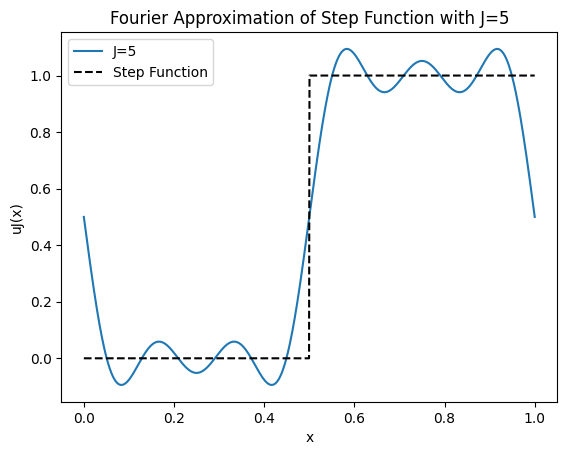

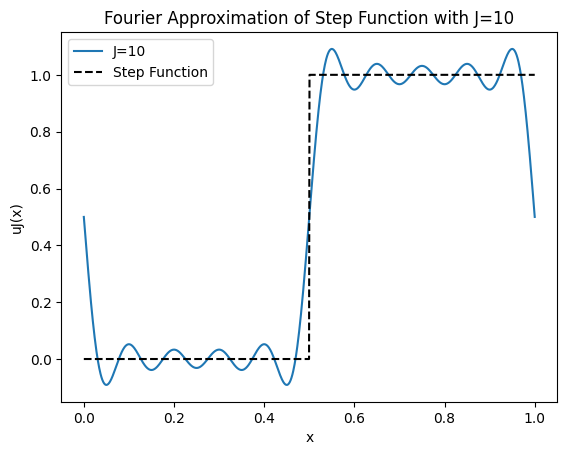

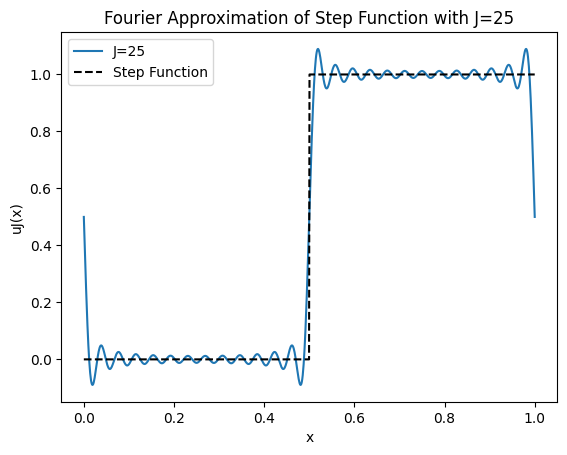

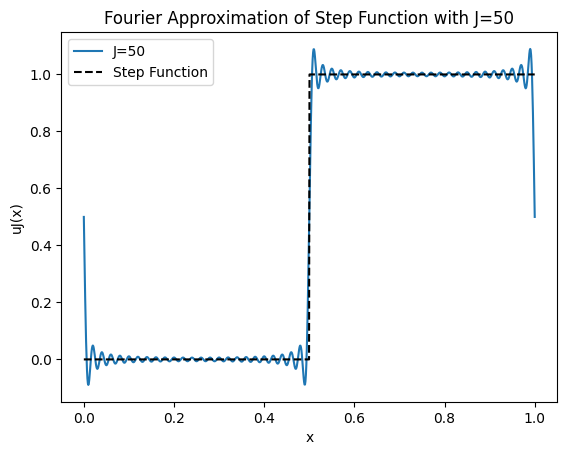

In [13]:
import numpy as np

u_k = lambda k: 1/2 if k == 0 else ((-1/(2j*k*np.pi)) * (1 - np.exp(-1j*k*np.pi)))
step_function = lambda x: 0 if x < 0.5 else 1

def  step_fn(J):
# Fourier approx to step function with 2J +1 terms
    N=1000
    grid=np.linspace(0,1,N)
    # FILL IN to define uJ

    uJ = np.zeros(N, dtype=complex)
    for k in range(-J, J+1):
        uJ += u_k(k) * np.exp(2j * np.pi * k * grid)

    return grid, uJ

import matplotlib.pyplot as plt
#Use plt to plot uJ for J=5,10,25,50

J_values = [5, 10, 25, 50]

for J in J_values:
    grid, uJ = step_fn(J)
    plt.plot(grid, np.real(uJ), label=f'J={J}')
    plt.plot(grid, [step_function(x) for x in grid], 'k--', label='Step Function')
    plt.title(f'Fourier Approximation of Step Function with J={J}')
    plt.xlabel('x')
    plt.ylabel('uJ(x)')
    plt.legend()
    plt.show()


The Gibbs phenomenon is the oscillatory behavior of the Fourier series of a piecewise continuously differentiable periodic function around a jump discontinuity. We see this clearly here at the point where x = 0.5 and y jumps from 0 to 1.

## A4

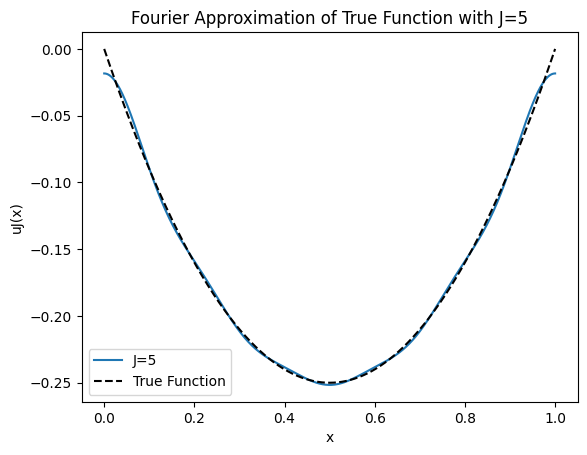

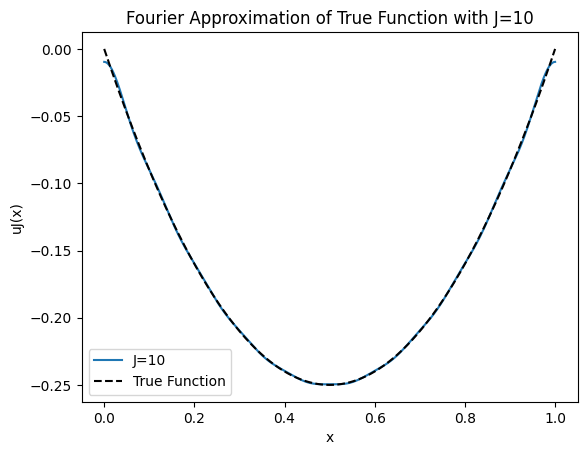

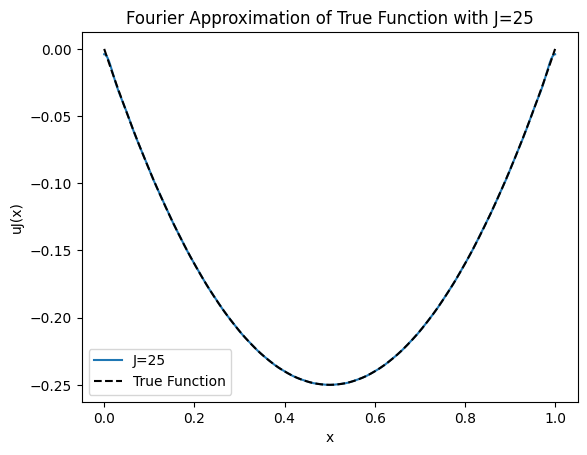

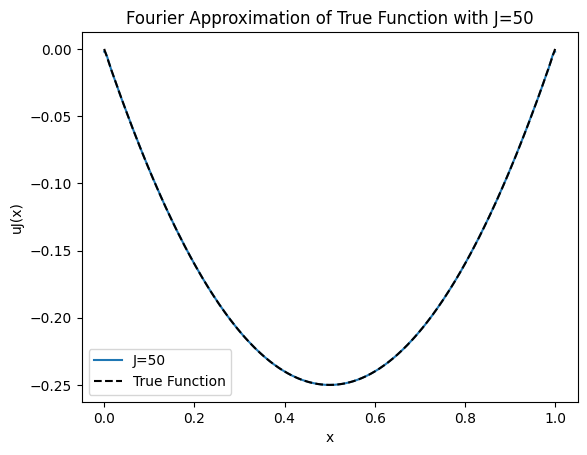

In [17]:

import numpy as np

u_k = lambda k: -1/6 if k == 0 else (1/(2*(np.pi**2)*(k**2)))
true_function = lambda x: x**2 - x

def  step_fn(J):
# Fourier approx to step function with 2J +1 terms
    N=1000
    grid=np.linspace(0,1,N)
    # FILL IN to define uJ

    uJ = np.zeros(N, dtype=complex)
    for k in range(-J, J+1):
        uJ += u_k(k) * np.exp(2j * np.pi * k * grid)

    return grid, uJ

import matplotlib.pyplot as plt
#Use plt to plot uJ for J=5,10,25,50

J_values = [5, 10, 25, 50]

for J in J_values:
    grid, uJ = step_fn(J)
    plt.plot(grid, np.real(uJ), label=f'J={J}')
    plt.plot(grid, [true_function(x) for x in grid], 'k--', label='True Function')
    plt.title(f'Fourier Approximation of True Function with J={J}')
    plt.xlabel('x')
    plt.ylabel('uJ(x)')
    plt.legend()
    plt.show()


## A5

# Section B

## B1

[np.float64(0.7182818284590453), np.float64(0.3939211931089812), np.float64(0.2704996730787903), np.float64(0.20584515245890933), np.float64(0.16610439152216183), np.float64(0.1392144883591513), np.float64(0.11981316179009904), np.float64(0.1051558505734338), np.float64(0.09369268555593369), np.float64(0.08448242849268284), np.float64(0.07692049275565704), np.float64(0.07060081519845318), np.float64(0.06524056717124149), np.float64(0.06063670827243017), np.float64(0.0566397074072309), np.float64(0.053137007018396076), np.float64(0.05004226175309445), np.float64(0.04728812860792386), np.float64(0.04482131254394406), np.float64(0.04259908524530043), np.float64(0.04058679015357547), np.float64(0.03875602250253252), np.float64(0.03708328050293308), np.float64(0.03554895127117952), np.float64(0.03413653843459996), np.float64(0.03283206678668771), np.float64(0.03162361838873062), np.float64(0.030500967461697615), np.float64(0.029455290366112274), np.float64(0.028478933251237626), np.float64(

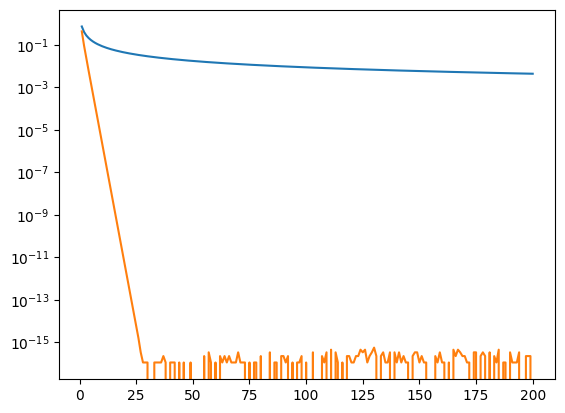

In [ ]:
from scipy.integrate import quad

def per_trap(u,J):
    #FILL IN

    I = 0

    for j in range(J):
        I += ((1/J) * u(j/J))

    return I


u_1 = lambda x: np.exp(x)
u_2 = lambda x: 1 / (2 - np.cos(2 * np.pi * x))

J_values = np.arange(1, 201)

for u in [u_1, u_2]:

    abs_errors = []

    for J in J_values:

        I = per_trap(u, J)
        quadval = quad(u, 0, 1)[0]
        absolute_error = abs(I - quadval)
        abs_errors.append(absolute_error)

    plt.semilogy(J_values, abs_errors)




## B2

## B3


# Section C

The size of img is (512, 512)


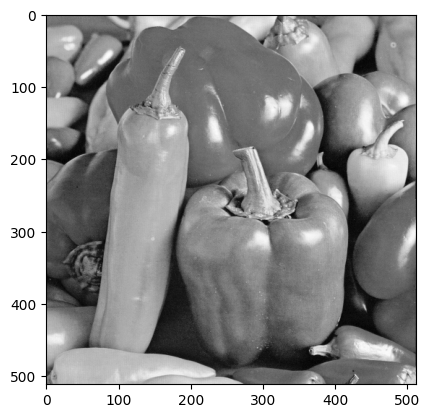

In [39]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
img = mpimg.imread('/Users/willbarnard/Downloads/image_peppers.tiff').mean(axis=2)
imgplot = plt.imshow(img, cmap='gray')
print('The size of img is', img.shape)

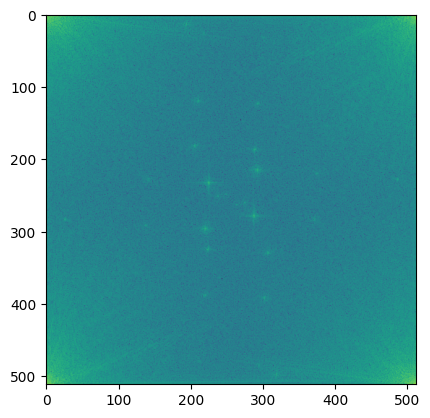

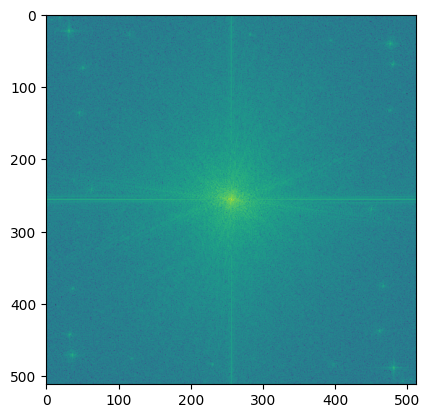

In [40]:
import numpy as np
from numpy.fft import fft2
fftim = fft2(img[:,:])
plt.imshow(np.log(np.abs(fftim))) # visualise absolute values of Fourier coefficients in log
plt.show()

from numpy.fft import fftshift
shiftim = fftshift(fftim)
plt.imshow(np.log(np.abs(shiftim))) # visualise absolute values of Fourier coefficients in lo
plt.show()

## C1

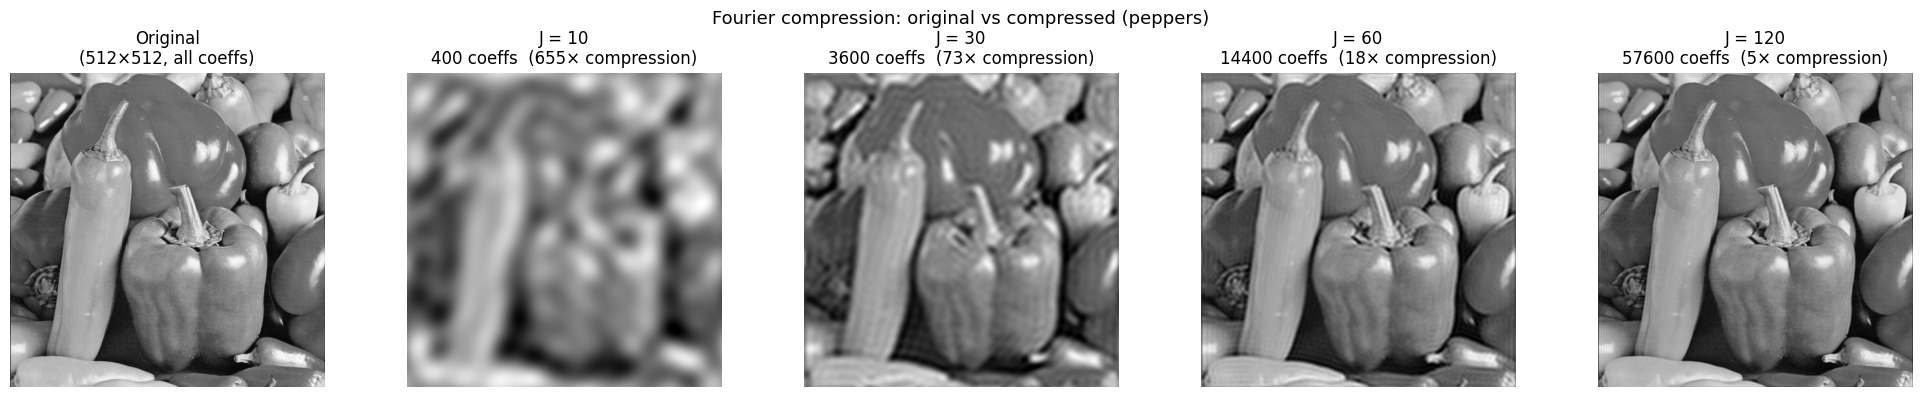

In [31]:
from scipy.fft import fft2, ifft2
import numpy as np
import matplotlib.pyplot as plt

def compress(A, J):
    # assume img is black-and-white or a slice A(:,:,i) of a rgb image
    Ahat = fft2(A)

    n, m = A.shape
    
    #FILL IN
    #Chat = #keep only most important  4J^2 coefficients in Ahat
    Chat = np.zeros_like(Ahat)
    Chat[:J,:J] = Ahat[:J,:J]   
    Chat[:J,m-J:] = Ahat[:J,m-J:]  
    Chat[n-J:,:J] = Ahat[n-J:,:J]  
    Chat[n-J:,m-J:] = Ahat[n-J:,m-J:]   
    
    C = np.real(ifft2(Chat)) #only interested in real part
    return C

J_values = [10, 30, 60, 120]
n, m = img.shape

fig, axes = plt.subplots(1, len(J_values) + 1, figsize=(20, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original\n(512×512, all coeffs)')
axes[0].axis('off')

for ax, J in zip(axes[1:], J_values):
    C = compress(img, J)
    kept  = 4 * J**2
    ratio = (n * m) / kept
    ax.imshow(np.clip(C, 0, 255), cmap='gray')
    ax.set_title(f'J = {J}\n{kept} coeffs  ({ratio:.0f}× compression)')
    ax.axis('off')

plt.suptitle('Fourier compression: original vs compressed (peppers)', fontsize=13)
plt.tight_layout()
plt.show()

**Image quality:**
- J = 10: heavily blurred, only broad shapes visible, 655× compression
- J = 30: overall structure clear but fine detail lost, 73× compression
- J = 60: good quality, sharp edges starting to return, 18× compression
- J = 120: near-original, most detail preserved, 5× compression

**Artefacts observed:**
- **Ringing (Gibbs phenomenon):** oscillatory halos around sharp edges (e.g. pepper outlines) — the 2D analogue of the Gibbs effect from Section A, caused by abruptly truncating high frequencies
- **Blurring:** fine textures and thin features are smoothed out as J decreases, since the discarded high-frequency components carry that detail
- **Boundary ringing:** `fft2` assumes the image is periodic, so mismatched edges in


## C2

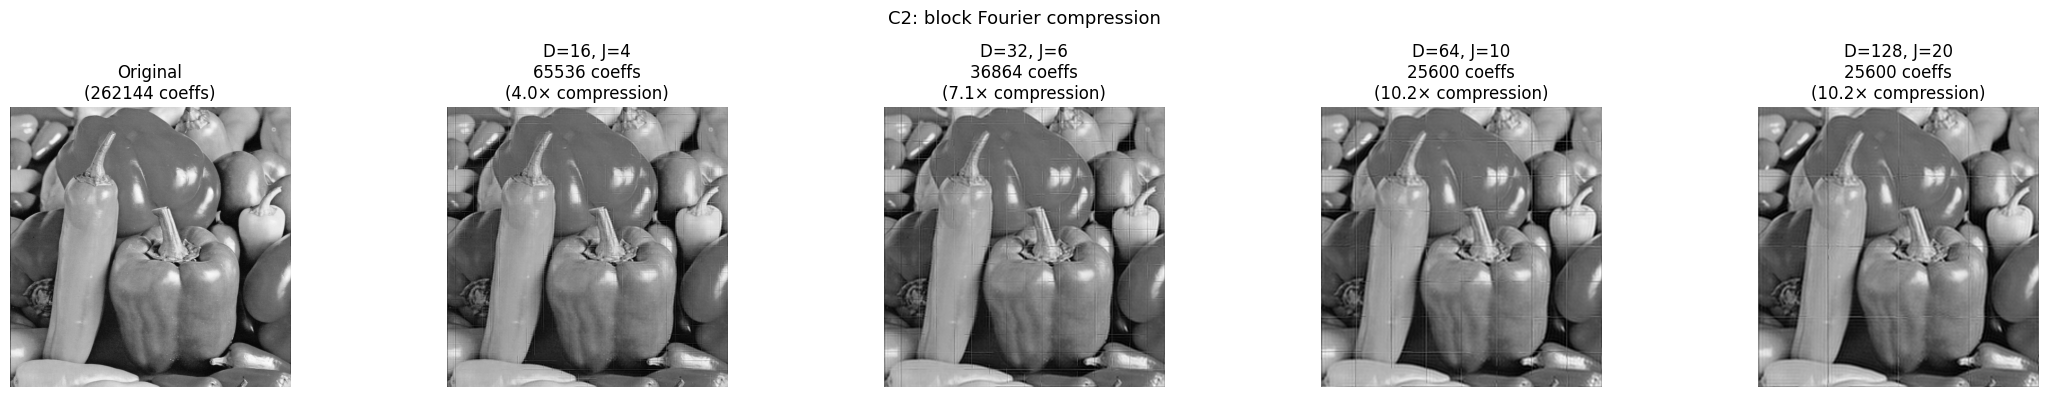

In [34]:
import matplotlib.pyplot as plt
import numpy as np

#inputs: image im
#        J = coefficients in each block
#        D = size of blocks
def compress_v2(im, J, D):
    # FILL IN
    n, m = im.shape
    C = np.zeros_like(im, dtype=float)
    total_coefficients = 0

    for i in range(0, n, D):
        for j in range(0, m, D):
            block = im[i:i+D, j:j+D]
            C[i:i+D, j:j+D] = compress(block, J)
            total_coefficients += 4 * J**2

    return C, total_coefficients


n, m = img.shape

configs = [(16, 4), (32, 6), (64, 10), (128, 20)]

fig, axes = plt.subplots(1, len(configs) + 1, figsize=(22, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original\n(262144 coeffs)')
axes[0].axis('off')

for ax, (D, J) in zip(axes[1:], configs):
    C, total = compress_v2(img, J, D)
    ax.imshow(np.clip(C, 0, 255), cmap='gray')
    ax.set_title(f'D={D}, J={J}\n{total} coeffs\n({n*m/total:.1f}× compression)')
    ax.axis('off')

plt.suptitle('C2: block Fourier compression', fontsize=13)
plt.tight_layout()
plt.show()

**Findings and comparison with C1:**

- Larger D with a well-chosen J gives better image quality at similar or higher compression than C1 — local frequency content is captured more faithfully than a single global transform
- Smaller D (e.g. D=16) introduces visible **block boundary artefacts** (grid lines) because each block is treated as periodic independently, creating artificial discontinuities at every boundary
- Gibbs ringing is **localised within each block** rather than spreading across the whole image, so it is less visually disruptive than in C1
- Very small blocks with small J can over-compress — smooth regions look fine but fine detail (thin edges, textures) is lost within each small block
- The best trade-off (qualitatively) is a medium block size like D=64 with J=10,